<a href="https://colab.research.google.com/github/khoadang31251024325-cmd/DangMinhKhoa_31251024325/blob/master/BT_20_4_26.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# BÀI 2.11

In [156]:
!pip install scikit-fuzzy -q
import numpy as np
import skfuzzy as fuzz
from skfuzzy import control as ctrl
import matplotlib.pyplot as plt

In [157]:
# Biến đầu vào
khoang_cach = ctrl.Antecedent(np.arange(0, 51, 1), 'khoang_cach')
luu_luong   = ctrl.Antecedent(np.arange(0, 101, 1), 'luu_luong')
nhu_cau     = ctrl.Antecedent(np.arange(0, 101, 1), 'nhu_cau')
thoi_tiet   = ctrl.Antecedent(np.arange(0, 11, 1), 'thoi_tiet')
danh_gia    = ctrl.Antecedent(np.arange(1, 5.1, 0.1), 'danh_gia')
dung_gio    = ctrl.Antecedent(np.arange(0, 101, 1), 'dung_gio')
# Biến đầu ra
gia_xe      = ctrl.Consequent(np.arange(0, 101, 1), 'gia_xe')
diem_thuong = ctrl.Consequent(np.arange(0, 101, 1), 'diem_thuong')



khoang_cach['ngan'] = fuzz.trimf(khoang_cach.universe, [0, 0, 3])
khoang_cach['trung_binh'] = fuzz.trimf(khoang_cach.universe, [2, 5, 8])
khoang_cach['dai'] = fuzz.trimf(khoang_cach.universe, [6, 13, 20])
khoang_cach['rat_xa'] = fuzz.trimf(khoang_cach.universe, [15, 50, 50])

luu_luong['thap'] = fuzz.trimf(luu_luong.universe, [0, 0, 30])
luu_luong['trung_binh'] = fuzz.trimf(luu_luong.universe, [20, 50, 70])
luu_luong['cao'] = fuzz.trimf(luu_luong.universe, [60, 100, 100])

nhu_cau['thap'] = fuzz.trimf(nhu_cau.universe, [0, 0, 30])
nhu_cau['trung_binh'] = fuzz.trimf(nhu_cau.universe, [20, 50, 70])
nhu_cau['cao'] = fuzz.trimf(nhu_cau.universe, [60, 100, 100])

thoi_tiet['tot'] = fuzz.trimf(thoi_tiet.universe, [7, 10, 10])
thoi_tiet['trung_binh'] = fuzz.trimf(thoi_tiet.universe, [3, 5, 7])
thoi_tiet['xau'] = fuzz.trimf(thoi_tiet.universe, [0, 0, 4])

danh_gia['kem'] = fuzz.trimf(danh_gia.universe, [1, 1, 2.5])
danh_gia['trung_binh'] = fuzz.trimf(danh_gia.universe, [2, 3, 4])
danh_gia['tot'] = fuzz.trimf(danh_gia.universe, [3.5, 5, 5])

dung_gio['tre'] = fuzz.trimf(dung_gio.universe, [0, 0, 50])
dung_gio['dung_gio'] = fuzz.trimf(dung_gio.universe, [40, 60, 80])
dung_gio['som'] = fuzz.trimf(dung_gio.universe, [70, 100, 100])



gia_xe['thap']       = fuzz.trimf(gia_xe.universe, [0, 0, 30])
gia_xe['trung_binh'] = fuzz.trimf(gia_xe.universe, [20, 35, 55])
gia_xe['cao']        = fuzz.trimf(gia_xe.universe, [45, 60, 80])
gia_xe['rat_cao']    = fuzz.trimf(gia_xe.universe, [70, 90, 100])

diem_thuong['khong_co']   = fuzz.trimf(diem_thuong.universe, [0, 0, 20])
diem_thuong['it']         = fuzz.trimf(diem_thuong.universe, [15, 35, 55])
diem_thuong['trung_binh'] = fuzz.trimf(diem_thuong.universe, [45, 65, 80])
diem_thuong['cao']        = fuzz.trimf(diem_thuong.universe, [75, 90, 100])

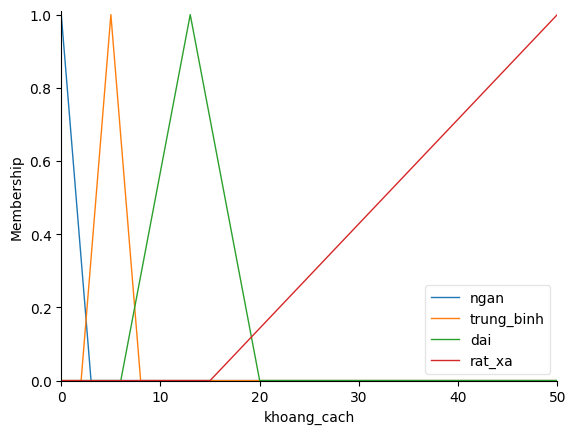

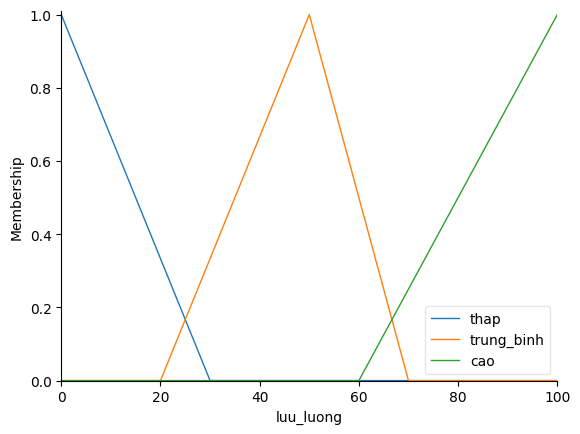

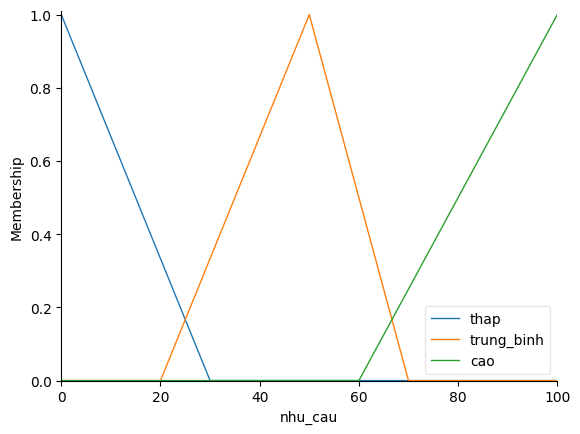

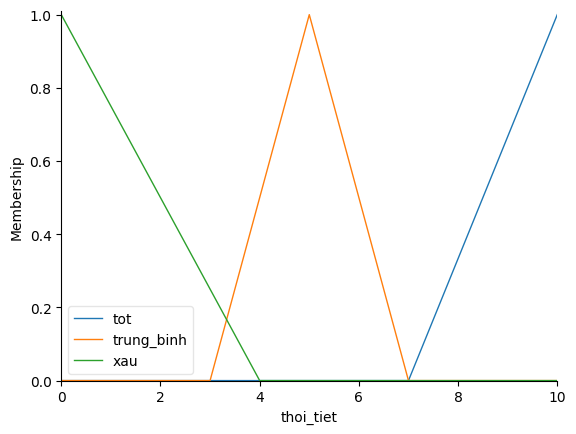

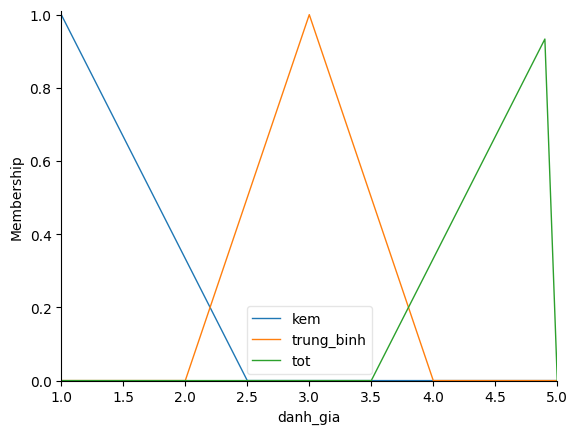

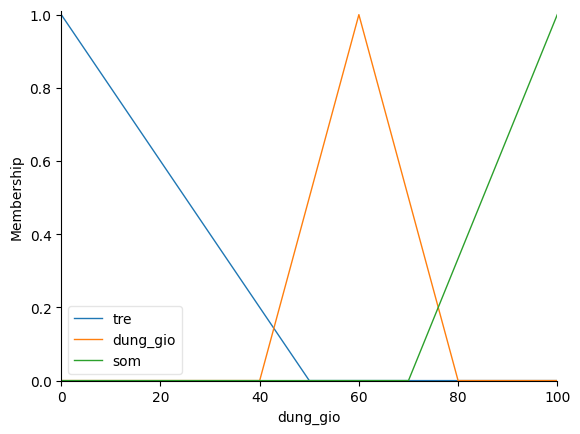

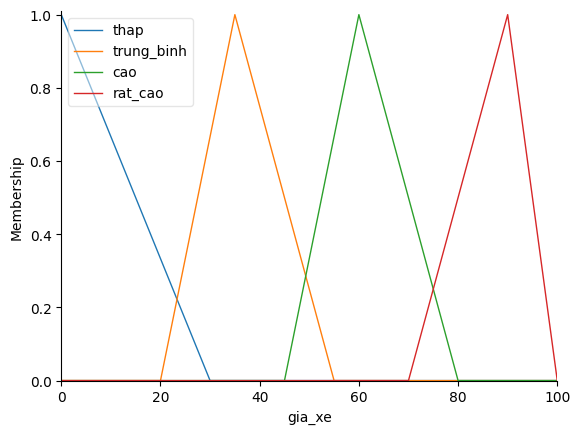

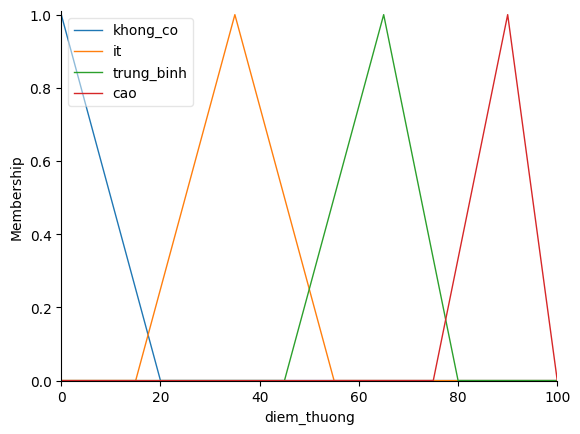

In [158]:
khoang_cach.view()
luu_luong.view()
nhu_cau.view()
thoi_tiet.view()
danh_gia.view()
dung_gio.view()

gia_xe.view()
diem_thuong.view()

In [159]:
# 10 Luật cho Giá xe
r1 = ctrl.Rule(khoang_cach['ngan'] & luu_luong['thap'] & nhu_cau['thap'], gia_xe['thap'])
r2 = ctrl.Rule(khoang_cach['ngan'] & luu_luong['trung_binh'] & nhu_cau['cao'], gia_xe['trung_binh'])
r3 = ctrl.Rule(khoang_cach['trung_binh'] & luu_luong['cao'] & nhu_cau['cao'], gia_xe['cao'])
r4 = ctrl.Rule(khoang_cach['dai'] & luu_luong['trung_binh'] & thoi_tiet['tot'], gia_xe['trung_binh'])
r5 = ctrl.Rule(khoang_cach['dai'] & luu_luong['cao'] & thoi_tiet['xau'], gia_xe['rat_cao'])
r6 = ctrl.Rule(khoang_cach['rat_xa'] & luu_luong['cao'] & nhu_cau['cao'], gia_xe['rat_cao'])
r7 = ctrl.Rule(khoang_cach['trung_binh'] & luu_luong['thap'] & nhu_cau['thap'], gia_xe['trung_binh'])
r8 = ctrl.Rule(khoang_cach['ngan'] & luu_luong['cao'] & thoi_tiet['xau'], gia_xe['cao'])
r9 = ctrl.Rule(khoang_cach['rat_xa'] & thoi_tiet['xau'], gia_xe['rat_cao'])
r10 = ctrl.Rule(khoang_cach['trung_binh'] & luu_luong['trung_binh'] & thoi_tiet['trung_binh'], gia_xe['trung_binh'])

# 10 Luật cho Điểm thưởng
r11 = ctrl.Rule(danh_gia['tot'] & dung_gio['som'], diem_thuong['cao'])
r12 = ctrl.Rule(danh_gia['trung_binh'] & dung_gio['dung_gio'], diem_thuong['trung_binh'])
r13 = ctrl.Rule(danh_gia['kem'] & dung_gio['tre'], diem_thuong['khong_co'])
r14 = ctrl.Rule(khoang_cach['dai'] & luu_luong['cao'] & dung_gio['dung_gio'], diem_thuong['cao'])
r15 = ctrl.Rule(khoang_cach['trung_binh'] & luu_luong['trung_binh'] & danh_gia['tot'], diem_thuong['trung_binh'])
r16 = ctrl.Rule(danh_gia['kem'] & dung_gio['tre'], diem_thuong['khong_co'])
r17 = ctrl.Rule(khoang_cach['rat_xa'] & thoi_tiet['xau'] & danh_gia['tot'], diem_thuong['cao'])
r18 = ctrl.Rule(khoang_cach['ngan'] & danh_gia['trung_binh'] & dung_gio['dung_gio'], diem_thuong['it'])
r19 = ctrl.Rule(khoang_cach['dai'] & luu_luong['cao'] & dung_gio['tre'], diem_thuong['it'])
r20 = ctrl.Rule(khoang_cach['trung_binh'] & thoi_tiet['trung_binh'] & danh_gia['tot'], diem_thuong['trung_binh'])

system_ctrl = ctrl.ControlSystem([r1,r2,r3,r4,r5,r6,r7,r8,r9,r10,r11,r12,r13,r14,r15,r16,r17,r18,r19,r20])
grab_sim = ctrl.ControlSystemSimulation(system_ctrl)

In [160]:
def check_grab_logic(title, kc, ll, nc, tt, dg, dgio):
    grab_sim.input['khoang_cach'] = kc
    grab_sim.input['luu_luong']   = ll
    grab_sim.input['nhu_cau']     = nc
    grab_sim.input['thoi_tiet']   = tt
    grab_sim.input['danh_gia']    = dg
    grab_sim.input['dung_gio']    = dgio

    grab_sim.compute()

    print(f"{title}")
    print(f"Khoảng cách: {kc}km | Lưu lượng xe: {ll}% | Thời tiết: {tt}/10")
    print(f"GIÁ: {grab_sim.output['gia_xe']:.2f} ")
    print(f"CHỈ SỐ THƯỞNG: {grab_sim.output['diem_thuong']:.2f}/100")
check_grab_logic("KẾT QUẢ CHUYẾN ĐI",
                 kc=4, ll=70, nc=70, tt=10, dg=4.0, dgio=50)

KẾT QUẢ CHUYẾN ĐI
Khoảng cách: 4km | Lưu lượng xe: 70% | Thời tiết: 10/10
GIÁ: 62.20 
CHỈ SỐ THƯỞNG: 62.50/100


# BÀI 2.12

In [161]:
import numpy as np
import skfuzzy as fuzz
from skfuzzy import control as ctrl
import matplotlib.pyplot as plt

In [162]:
#Biến đầu vào
xep_hang = ctrl.Antecedent(np.arange(1, 5.1, 0.1), 'xep_hang')
kl_ban   = ctrl.Antecedent(np.arange(0, 1001, 1), 'kl_ban')
bien_ln  = ctrl.Antecedent(np.arange(0, 101, 1), 'bien_ln')
su_kien  = ctrl.Antecedent(np.arange(0, 11, 0.1), 'su_kien')
doi_thu  = ctrl.Antecedent(np.arange(0, 71, 1), 'doi_thu')
#Biến đầu ra
chiet_khau = ctrl.Consequent(np.arange(0, 71, 1), 'chiet_khau')


#Hàm thuộc
xep_hang['thap']       = fuzz.trimf(xep_hang.universe, [1.0, 1.0, 4.0])
xep_hang['trung_binh'] = fuzz.trimf(xep_hang.universe, [4.0, 4.25, 4.5])
xep_hang['cao']        = fuzz.trimf(xep_hang.universe, [4.5, 5.0, 5.0])

kl_ban['thap']       = fuzz.trimf(kl_ban.universe, [0, 0, 400])
kl_ban['trung_binh'] = fuzz.trimf(kl_ban.universe, [200, 500, 800])
kl_ban['cao']        = fuzz.trimf(kl_ban.universe, [600, 1000, 1000])

bien_ln['thap']       = fuzz.trimf(bien_ln.universe, [0, 0, 40])
bien_ln['trung_binh'] = fuzz.trimf(bien_ln.universe, [20, 50, 80])
bien_ln['cao']        = fuzz.trimf(bien_ln.universe, [60, 100, 100])

su_kien['khong_co']   = fuzz.trimf(su_kien.universe, [0, 0, 4])
su_kien['trung_binh'] = fuzz.trimf(su_kien.universe, [3, 5, 7])
su_kien['cao']        = fuzz.trimf(su_kien.universe, [6, 10, 10])

doi_thu['thap']       = fuzz.trimf(doi_thu.universe, [0, 0, 25])
doi_thu['trung_binh'] = fuzz.trimf(doi_thu.universe, [15, 35, 55])
doi_thu['cao']        = fuzz.trimf(doi_thu.universe, [45, 70, 70])


chiet_khau['rat_thap']   = fuzz.trimf(chiet_khau.universe, [0, 2.5, 5])
chiet_khau['thap']       = fuzz.trimf(chiet_khau.universe, [5, 7.5, 10])
chiet_khau['trung_binh'] = fuzz.trimf(chiet_khau.universe, [10, 15, 20])
chiet_khau['cao']        = fuzz.trimf(chiet_khau.universe, [20, 30, 40])
chiet_khau['rat_cao']    = fuzz.trimf(chiet_khau.universe, [40, 55, 70])

In [163]:
rule1 = ctrl.Rule(xep_hang['cao'] & kl_ban['cao'] & bien_ln['cao'], chiet_khau['rat_thap'])
rule2 = ctrl.Rule(xep_hang['thap'] & kl_ban['thap'] & bien_ln['cao'], chiet_khau['cao'])
rule3 = ctrl.Rule(su_kien['cao'] & doi_thu['cao'], chiet_khau['rat_cao'])
rule4 = ctrl.Rule(xep_hang['trung_binh'] & kl_ban['trung_binh'] & bien_ln['trung_binh'], chiet_khau['trung_binh'])
rule5 = ctrl.Rule(doi_thu['thap'] & bien_ln['thap'] & kl_ban['cao'], chiet_khau['rat_thap'])
rule6 = ctrl.Rule(xep_hang['thap'] & su_kien['khong_co'], chiet_khau['trung_binh'])
rule7 = ctrl.Rule(kl_ban['thap'] & bien_ln['thap'], chiet_khau['rat_cao'])

rules = [rule1, rule2, rule3, rule4, rule5, rule6, rule7]
shopee_ctrl = ctrl.ControlSystem(rules)

Mức chiết khấu tính toán: 36.94%


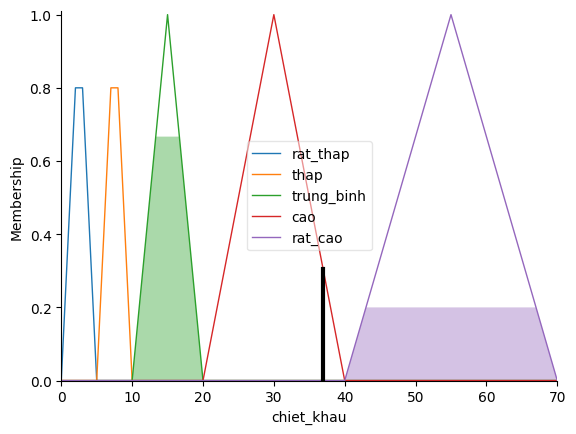

In [164]:
shopee_ctrl = ctrl.ControlSystem(rules)
shopee_sim  = ctrl.ControlSystemSimulation(shopee_ctrl)

shopee_sim.input['xep_hang'] = 4.3
shopee_sim.input['kl_ban']   = 500  # Trung bình
shopee_sim.input['bien_ln']  = 40   # Ngưỡng giữa Thấp và Trung bình
shopee_sim.input['su_kien']  = 7.0  # Cao
shopee_sim.input['doi_thu']  = 50   # Trung bình/Cao

shopee_sim.compute()
result = shopee_sim.output['chiet_khau']

print(f"Mức chiết khấu tính toán: {result:.2f}%")
chiet_khau.view(sim=shopee_sim)
plt.show()

# BÀI 2.13

In [165]:
!pip install scikit-fuzzy
import numpy as np
import skfuzzy as fuzzy
from skfuzzy import control as ctrl
import matplotlib.pyplot as plt

In [166]:
#Đầu vào
nhu_cau = ctrl.Antecedent(np.arange(0, 11, 1), 'nhu_cau')
ap_luc_doi_thu = ctrl.Antecedent(np.arange(0, 11, 1), 'ap_luc_doi_thu')
mua_vu = ctrl.Antecedent(np.arange(0, 11, 1), 'mua_vu')
bien_loi_nhuan = ctrl.Antecedent(np.arange(0, 101, 1), 'bien_loi_nhuan')
uy_tin = ctrl.Antecedent(np.arange(0, 5.1, 0.1), 'uy_tin')

# Đầu ra
chiet_khau = ctrl.Consequent(np.arange(0, 71, 1), 'chiet_khau')

for var in [nhu_cau, ap_luc_doi_thu, mua_vu]:
    var['thap'] = fuzzy.trimf(var.universe, [0, 0, 5])
    var['trung_binh'] = fuzzy.trimf(var.universe, [2, 5, 8])
    var['cao'] = fuzzy.trimf(var.universe, [5, 10, 10])

uy_tin['thap'] = fuzzy.trimf(uy_tin.universe, [0, 0, 4.0])
uy_tin['trung_binh'] = fuzzy.trimf(uy_tin.universe, [3.8, 4.2, 4.5])
uy_tin['cao'] = fuzzy.trimf(uy_tin.universe, [4.3, 5.0, 5.0])

bien_loi_nhuan['thap'] = fuzzy.trimf(bien_loi_nhuan.universe, [0, 0, 30])
bien_loi_nhuan['trung_binh'] = fuzzy.trimf(bien_loi_nhuan.universe, [20, 50, 70])
bien_loi_nhuan['cao'] = fuzzy.trimf(bien_loi_nhuan.universe, [60, 100, 100])

chiet_khau['rat_thap'] = fuzzy.trimf(chiet_khau.universe, [0, 0, 5])
chiet_khau['thap'] = fuzzy.trimf(chiet_khau.universe, [5, 7.5, 10])
chiet_khau['trung_binh'] = fuzzy.trimf(chiet_khau.universe, [10, 17.5, 25])
chiet_khau['cao'] = fuzzy.trimf(chiet_khau.universe, [20, 30, 40])
chiet_khau['rat_cao'] = fuzzy.trimf(chiet_khau.universe, [40, 55, 70])

In [167]:
rule1 = ctrl.Rule(nhu_cau['cao'] & ap_luc_doi_thu['thap'] & bien_loi_nhuan['thap'], chiet_khau['rat_thap'])
rule2 = ctrl.Rule(nhu_cau['thap'] & ap_luc_doi_thu['cao'] & bien_loi_nhuan['cao'], chiet_khau['cao'])
rule3 = ctrl.Rule(uy_tin['cao'] & bien_loi_nhuan['trung_binh'] & mua_vu['cao'], chiet_khau['trung_binh'])
rule4 = ctrl.Rule(ap_luc_doi_thu['cao'] & mua_vu['cao'] & bien_loi_nhuan['cao'], chiet_khau['rat_cao'])
rule5 = ctrl.Rule(uy_tin['thap'] & nhu_cau['trung_binh'] & bien_loi_nhuan['thap'], chiet_khau['trung_binh'])
rule6 = ctrl.Rule(nhu_cau['cao'] & mua_vu['thap'] & ap_luc_doi_thu['thap'], chiet_khau['rat_thap'])
rule7 = ctrl.Rule(bien_loi_nhuan['cao'] & ap_luc_doi_thu['trung_binh'] & mua_vu['cao'], chiet_khau['trung_binh'])

rules = [rule1, rule2, rule3, rule4, rule5, rule6, rule7]
shopee_system = ctrl.ControlSystem(rules)
shopee_sim = ctrl.ControlSystemSimulation(shopee_system)

TÌNH HUỐNG: ĐỒNG HỒ XA XỈ THỦ CÔNG
Kết quả: 17.50%


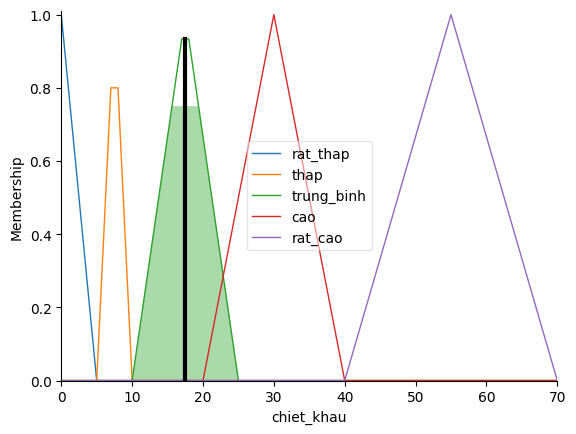

In [168]:
shopee_sim = ctrl.ControlSystemSimulation(ctrl.ControlSystem(rules))
shopee_sim.input['nhu_cau'] = 9             # Cao
shopee_sim.input['ap_luc_doi_thu'] = 5      # Trung bình
shopee_sim.input['uy_tin'] = 4.2           # Trung bình
shopee_sim.input['bien_loi_nhuan'] = 90     # Cao
shopee_sim.input['mua_vu'] = 10            # Cao

shopee_sim.compute()
print(f"TÌNH HUỐNG: ĐỒNG HỒ XA XỈ THỦ CÔNG")
print(f"Kết quả: {shopee_sim.output['chiet_khau']:.2f}%")

chiet_khau.view(sim=shopee_sim)
plt.show()

# BÀI 2.14

In [169]:
import numpy as np
import skfuzzy as fuzz
from skfuzzy import control as ctrl
import matplotlib.pyplot as plt

In [170]:
#BIẾN ĐẦU VÀO
order_density = ctrl.Antecedent(np.arange(0, 11, 1), 'order_density')
delivery_urgency = ctrl.Antecedent(np.arange(0, 11, 1), 'delivery_urgency')
driver_load = ctrl.Antecedent(np.arange(0, 11, 1), 'driver_load')
traffic_conditions = ctrl.Antecedent(np.arange(0, 11, 1), 'traffic_conditions')
profit_per_delivery = ctrl.Antecedent(np.arange(0, 11, 1), 'profit_per_delivery')

#BIẾN ĐẦU RA
num_orders_combine = ctrl.Consequent(np.arange(0, 11, 1), 'num_orders_combine')
delivery_priority = ctrl.Consequent(np.arange(0, 11, 1), 'delivery_priority')



names = ['thap', 'trung_binh', 'cao']
for var in [order_density, delivery_urgency, driver_load, traffic_conditions, profit_per_delivery, delivery_priority]:
    var.automf(names=names)

num_orders_combine.automf(names=['it', 'mot_so', 'nhieu'])

In [171]:
# Nhóm luật: Kết hợp đơn hàng
rule1 = ctrl.Rule(order_density['cao'] & driver_load['thap'] & traffic_conditions['thap'],
                  num_orders_combine['nhieu'])

rule2 = ctrl.Rule(order_density['trung_binh'] & traffic_conditions['cao'] & delivery_urgency['trung_binh'],
                  num_orders_combine['mot_so'])

rule3 = ctrl.Rule(driver_load['cao'] & order_density['cao'] & profit_per_delivery['trung_binh'],
                  num_orders_combine['mot_so'])

rule4 = ctrl.Rule(order_density['thap'] & delivery_urgency['cao'] & traffic_conditions['trung_binh'],
                  num_orders_combine['mot_so'])

rule5 = ctrl.Rule(profit_per_delivery['cao'] & delivery_urgency['cao'] & traffic_conditions['cao'],
                  num_orders_combine['mot_so'])

# Nhóm luật: Ưu tiên giao hàng
rule6 = ctrl.Rule(delivery_urgency['cao'] & profit_per_delivery['cao'],
                  delivery_priority['cao'])

rule7 = ctrl.Rule(delivery_urgency['trung_binh'] & traffic_conditions['trung_binh'],
                  delivery_priority['trung_binh'])

rule8 = ctrl.Rule(delivery_urgency['thap'] & order_density['cao'] & profit_per_delivery['thap'],
                  delivery_priority['thap'])

delivery_ctrl = ctrl.ControlSystem([rule1, rule2, rule3, rule4, rule5, rule6, rule7, rule8])
delivery_sim = ctrl.ControlSystemSimulation(delivery_ctrl)

KẾT QUẢ TÍNH TOÁN
Số lượng đơn hàng kết hợp: 8.14
Mức độ ưu tiên giao hàng: 5.00


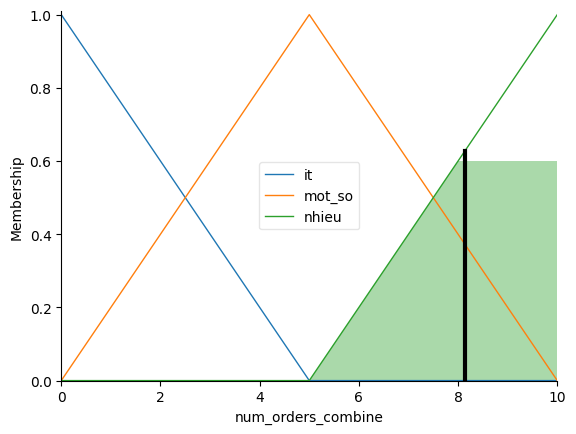

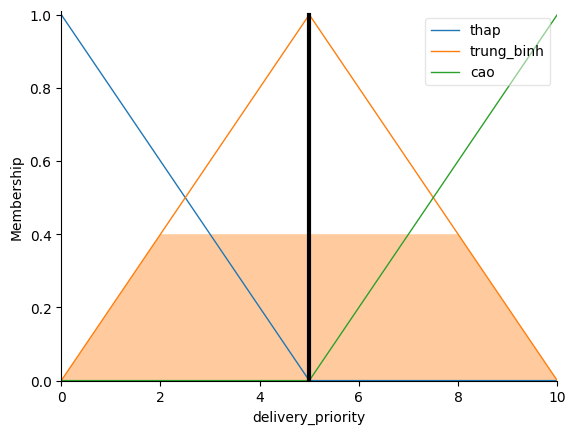

In [172]:
delivery_ctrl = ctrl.ControlSystem([rule1, rule2, rule3, rule4, rule5, rule6, rule7, rule8])
delivery_sim = ctrl.ControlSystemSimulation(delivery_ctrl)

delivery_sim.input['order_density'] = 8       # Cao
delivery_sim.input['delivery_urgency'] = 5    # Trung bình
delivery_sim.input['driver_load'] = 2         # Thấp
delivery_sim.input['traffic_conditions'] = 2  # Thấp
delivery_sim.input['profit_per_delivery'] = 5 # Trung bình

delivery_sim.compute()


print("KẾT QUẢ TÍNH TOÁN")
print(f"Số lượng đơn hàng kết hợp: {delivery_sim.output['num_orders_combine']:.2f}")
print(f"Mức độ ưu tiên giao hàng: {delivery_sim.output['delivery_priority']:.2f}")


num_orders_combine.view(sim=delivery_sim)
delivery_priority.view(sim=delivery_sim)
plt.show()